### Baseline intensidad del incendio (frp)
Estableceremos dos baselines: la media y la mediana

In [44]:
import extraccion.minioFunctions as mf
from sklearn.model_selection import train_test_split, cross_validate # separación de datos y obtención de métricas
from sklearn.tree import DecisionTreeClassifier # modelo de árbol de decisión
from sklearn.linear_model import LinearRegression # modelo de regresión logística
from sklearn.preprocessing import StandardScaler # normalización de nuestros datos
import matplotlib.pyplot as plt # graficar resultados
import seaborn as sns # para los boxplots
import pandas as pd # manipulación de los dataframes
import numpy as np  # operaciones con arrays

### Carga de datos

In [45]:
cliente = mf.crear_cliente()
df = mf.bajar_fichero(cliente, "grupo3/cleaned/Modelo_Incendios_final.parquet")

#Dividimos en variable explicativa y respuesta
df2 = df.copy()
y = df2["frp_mean"]
df2.drop(columns = ["frp_mean"], inplace = True)
X = df2

Dataframe importado correctamente


In [46]:
X.head()

,lat,lon,frp_sum,count,date,date_last,duration_days,area_ha,final,elevacion_centro,grados,porcentaje,temp_mean,temp_max,temp_min,humidity_mean,precipitation,wind_speed_max,wind_gusts_max,pressure_mean,cloud_cover,radiation,evapotranspiration,sunshine_seconds,NDVI,NDWI
0,35.026970,32.472335,403.04,4.0,2022-08-22,2022-08-22,1.0,126.14,1,238.054031,6.640842,11.642637,26.1,29.8,23.9,78.0,0.0,17.6,42.1,981.6,16.0,24.98,4.97,43346.05,0.171024,-0.295281
1,35.038019,-5.644138,3670.35,35.0,2022-07-14,2022-07-16,3.0,2506.15,1,185.857239,10.259732,18.100486,31.8,42.3,23.2,24.0,0.0,19.2,48.6,991.9,0.0,29.08,8.45,46800.00,0.476860,-0.416024
2,35.110292,-5.739932,2074.66,18.0,2022-07-14,2022-10-06,85.0,3904.65,1,484.057281,6.400329,11.217379,31.8,41.5,22.5,19.0,0.0,17.1,40.7,958.6,0.0,28.98,7.86,46800.00,0.419240,-0.360726
3,35.174872,-6.158635,269.21,4.0,2022-07-14,2022-07-14,1.0,50.31,1,35.344204,0.644440,1.124807,30.1,39.2,22.2,55.0,0.0,22.2,36.7,1008.9,0.0,28.43,7.80,46800.00,0.106745,-0.177780
4,35.241360,-5.424180,57.19,1.0,2022-07-27,2022-07-27,1.0,14.06,1,1278.932373,31.858154,62.143233,19.6,26.7,12.4,43.0,0.0,11.0,37.8,872.5,0.0,28.35,5.92,46800.00,0.546387,-0.522883


### Baseline intensidad del incendio (frp)

In [47]:
print(f"Valor medio de frp: {y.mean()}")
print(f"Mediana de frp: {y.median()}")

Valor medio de frp: 88.45918227221395
Mediana de frp: 76.35368421052632


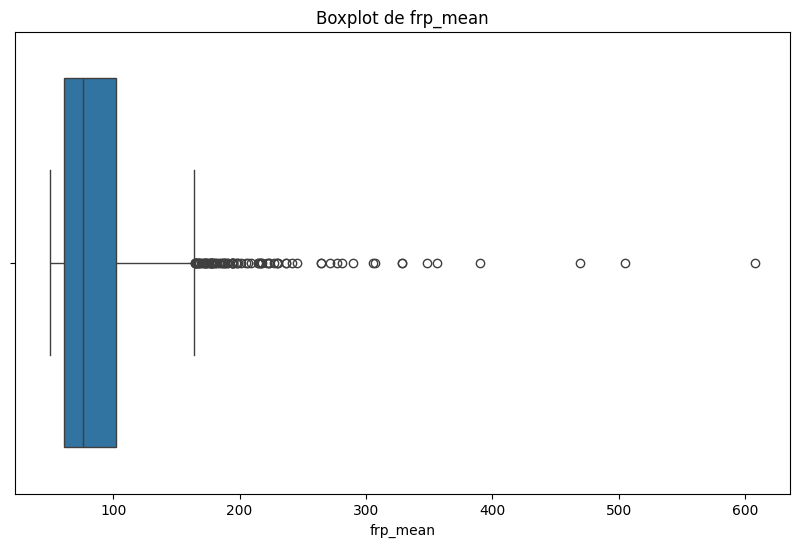

In [48]:
# Lo vemos gráficamente
plt.figure(figsize=(10, 6))
sns.boxplot(x=y)
plt.title("Boxplot de frp_mean")
plt.xlabel("frp_mean")
plt.show()

### Variables más significativas

##### División de los datos

In [49]:
X.drop(columns=["date", "date_last", "frp_sum"], inplace = True)

In [50]:
X_train, X_div, y_train, y_div = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_div, y_div, test_size=0.5, random_state=42)

print(f"Tamaño conjunto de entrenamiento: {len(X_train)}")
print(f"Tamaño conjunto de prueba: {len(X_test)}")
print(f"Tamaño conjunto de validación: {len(X_val)}")

Tamaño conjunto de entrenamiento: 1620
Tamaño conjunto de prueba: 203
Tamaño conjunto de validación: 203


### Regresión lineal
Observamos las variables a las que más peso se le dan

In [51]:
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
std_X_train_norm = np.sqrt(scaler.var_)

mean_X_train_norm = np.mean(X_train_norm)
print(f"La media es: {mean_X_train_norm}")
std_X_train_norm = np.std(X_train_norm)
print(f"La desviación estándar es: {std_X_train_norm}")

La media es: 7.132125152288714e-17
La desviación estándar es: 0.9780192938436515


In [ ]:
rl = LinearRegression()
rl.fit(X_train_norm, y_train)

importancias = rl.coef_
variables = X.columns

df_importancias = pd.DataFrame({"Variable": variables, "Pesos": importancias}).sort_values(by = "Pesos", ascending = False, ignore_index=True)
df_importancias

,Variable,Pesos
0,grados,7.431759e+00
1,count,7.295432e+00
2,temp_mean,6.682594e+00
3,NDVI,5.854451e+00
4,evapotranspiration,4.658975e+00
5,temp_max,3.846393e+00
6,sunshine_seconds,2.935124e+00
7,wind_gusts_max,2.597104e+00
8,NDWI,2.213900e+00
9,humidity_mean,9.681602e-01
